# 1. Import Ntuple and DecayHash

In [1]:
import glob
import numpy as np
import pandas
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
plt.style.use('belle2')
from tqdm import tqdm
import pyhf
pyhf.set_backend('numpy','minuit')
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.tab20.colors)

In [2]:
import json
import yaml

workspace_file = '/home/belle/zhangboy/R_D/Signal_MC14ri/2d_2channels_workspace_3.json'
results = 'results_3.yaml'
with open(workspace_file, 'r+') as work_f:
    spec = json.load(work_f)
#    spec['observations'][0]['name'] = 'electron mode'
#    spec['observations'][0]['data'] = counts.ravel().tolist()
    spec_1 = {'channels': spec['channels']}
    model_1 = pyhf.Model(spec_1, poi_name=None)
    NumOfComp = len(spec['channels'][0]['samples'])
#model_1.spec
#workspace = pyhf.Workspace(spec)
#workspace

In [3]:
def statistics(df):
    counts=df.count()
    mean=df.mean()
    std=df.std()
    return f'''counts = %d \nmean = %5.3f \nstd = %5.3f''' %(counts,mean,std)

kwarg={'histtype':'step','lw':2}
    

plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.tab20.colors)

def plot_all_signals(cut, variable):
    fig,axs =plt.subplots(2,3,figsize=(16,10), sharex=True, sharey=False)
    fig.suptitle(f'All signals with {cut}')
    fig.supylabel('# of candidates per bin',x=0.06)
    fig.supxlabel(f'{variable}', y=0.06)
    i=0
    j=0
    for sample_name, sample in samples.items():
        (counts, bins) = np.histogram(sample.query(cut)[variable], bins=50)
        if sample_name in ['sig_D_l_nu','sig_D_tau_nu','bkg_fakeDTC','bkg_fakeB','bkg_continuum','bkg_others']:
            factor = 1
        elif sample_name in ['sig_Dst_l_nu','sig_Dst_tau_nu','all_Dstst_l_nu','all_Dstst_tau_nu']:
            factor = 1
        axs[i,j].hist(bins[:-1], bins, weights=factor*counts,label=sample_name,**kwarg)

        #plt.legend(bbox_to_anchor=(1,1),ncol=3, fancybox=True, shadow=True,labelspacing=1.5)
        axs[i,j].grid()
        axs[i,j].set_title(sample_name)
        j+=1
        if j==3:
            i+=1
            j=0
            
def plot_all_signals_2d(cut):
    variable_x = 'B0_CMS3_weMissM2'
    variable_y = 'p_D_l'
    xedges = np.linspace(-2, 10, 48)
    yedges = np.linspace(0.4, 4.6, 42)

    n_rows,n_cols = [2,3]
    fig,axs=plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(16,8),sharex=True, sharey='all')
    fig.suptitle('Signals')
    fig.supylabel('$|p_D|\ +\ |p_l|\ [GeV]$', x=0.05)
    fig.supxlabel('$M_{miss}^2\ [GeV^2/c^4]$')
    i=0
    j=0
    for name, sample in samples.items():
        (counts, xedges, yedges) = np.histogram2d(sample.query(cut)[variable_x], 
                                              sample.query(cut)[variable_y],
                                              bins=[xedges, yedges])
        counts = counts.T + 0.01
        X, Y = np.meshgrid(xedges, yedges)
        im=axs[i,j].pcolormesh(X, Y, counts, cmap='jet', norm=colors.LogNorm())
        axs[i,j].grid()
        axs[i,j].set_xlim(xedges.min(),xedges.max())
        axs[i,j].set_ylim(yedges.min(),yedges.max())
        axs[i,j].set_title(name,fontsize=12)
        fig.colorbar(im,ax=axs[i,j])
        j+=1
        if j==3:
            i+=1
            j=0
            
def plot_overlaid_signals(cut, variable):
    fig,axs =plt.subplots(1,2,figsize=(12,5), sharex=True, sharey=False)
    fig.suptitle(f'Overlaid signals with pre-selection', y=1)
    fig.supylabel('# of candidates per bin',x=0.06)
    #fig.supxlabel('$|\\vec{p_D}|\ +\ |\\vec{p_l}|$  [GeV/c]')
    #fig.supxlabel('$M_{miss}^2 \ [GeV^2/c^4]$')
    fig.supxlabel(f'{variable}')

    for sample_name, sample in samples.items():
        (counts, bins) = np.histogram(sample.query(cut)[variable], bins=50)
        factor=1
        if sample_name in ['sig_D_tau_nu','sig_Dst_tau_nu','all_Dstst_tau_nu']:
            axs[0].hist(bins[:-1], bins, weights=factor*counts,label=sample_name,**kwarg)
            axs[0].legend()
        elif sample_name in ['sig_D_l_nu','sig_Dst_l_nu','all_Dstst_l_nu']:
            axs[1].hist(bins[:-1], bins, weights=factor*counts,label=sample_name,**kwarg)
            axs[1].legend()
        #plt.legend(bbox_to_anchor=(1,1),ncol=3, fancybox=True, shadow=True,labelspacing=1.5)

    axs[0].set_title('signals')
    axs[1].set_title('normalization')
    axs[0].grid()
    axs[1].grid()
    
def plot_overlaid_signals_2(cut, variable):
    fig,axs =plt.subplots(figsize=(12,5), sharex=True, sharey=False)
    fig.suptitle(f'Overlaid signals with pre-selection', y=1)
    fig.supylabel('# of candidates per bin',x=0.06)
    #fig.supxlabel('$|\\vec{p_D}|\ +\ |\\vec{p_l}|$  [GeV/c]')
    #fig.supxlabel('$M_{miss}^2 \ [GeV^2/c^4]$')
    fig.supxlabel(f'{variable}')

    for sample_name, sample in samples.items():
        if sample_name in ['sig_D_tau_nu']:
            (counts, bins) = np.histogram(sample.query(cut)[variable], bins=50)
            factor=1
        elif sample_name in ['all_Dstst_l_nu']:
            (counts, bins) = np.histogram(sample.query(cut)[variable], bins=50)
            factor=1
        else:
            continue
        axs.hist(bins[:-1], bins, weights=factor*counts,label=sample_name,**kwarg)
        axs.legend()
        #plt.legend(bbox_to_anchor=(1,1),ncol=3, fancybox=True, shadow=True,labelspacing=1.5)
    axs.grid()
    
def plot_projection(cut,variable):
    fig,axs =plt.subplots(sharex=True, sharey=False)
    for sample_name, sample in samples.items():
        (counts, bins) = np.histogram(sample.query(cut)[variable], bins=50)
        factor=1
        if sample_name in ['sig_D_tau_nu','sig_Dst_tau_nu','all_Dstst_tau_nu']:
            axs.hist(bins[:-1], bins, weights=factor*counts,label=f'{sample_name} \n{statistics(sample.query(cut)[variable])}',**kwarg)
        elif sample_name in ['sig_D_l_nu','sig_Dst_l_nu','all_Dstst_l_nu']:
            axs.hist(bins[:-1], bins, weights=factor*counts,label=f'{sample_name} \n{statistics(sample.query(cut)[variable])}',**kwarg)

    axs.set_title('Overlaid signals with pre-selection')
    axs.set_xlabel(f'{variable}')
    axs.set_ylabel('# of candidates per bin')
    axs.grid()
    plt.legend(bbox_to_anchor=(1,1),ncol=3, fancybox=True, shadow=True,labelspacing=1.5)
    
    
def plot_fitting_difference(yaml_file):
    fig,axs =plt.subplots(2,3,figsize=(16,10), sharex=True, sharey=False)
    fig.suptitle(f'fitted yield - true yield')
    fig.supylabel('yield difference',x=0.06)
    fig.supxlabel(f'index of subset samples', y=0.06)
    i=0
    j=0
    with open(yaml_file, 'r+') as f:
        data = yaml.safe_load(f)
        components = data['signal_e']

    for comp_name, info in components.items():
        axs[i,j].errorbar(x=range(1,len(info['difference'])+1), y=info['difference'], yerr=info['errors'], fmt='ko')
        axs[i,j].axhline(y=0, linestyle='-', linewidth=3, color='r')
        axs[i,j].grid()
        axs[i,j].set_title(comp_name)
        j+=1
        if j==3 and i==0:
            i+=1
            j=0
        if j==3 and i==1:
            break

In [5]:
# read in root-file as a pandas dataframe
Dstst_e_nu_selection = 'DecayMode=="all_Dstst_e_nu" and D_mcPDG*e_mcPDG==411*11 and e_genMotherPDG==B0_mcPDG and \
    ((B0_mcErrors<64 and B0_mcPDG*D_mcPDG==-511*411) or (B0_mcErrors<512 and abs(B0_mcPDG)==521))'
Dstst_tau_nu_selection = 'DecayMode=="all_Dstst_tau_nu" and D_mcPDG*e_mcPDG==411*11 and e_mcPDG*e_genMotherPDG==11*15 and \
    ((B0_mcErrors<64 and B0_mcPDG*D_mcPDG==-511*411) or (B0_mcErrors<512 and abs(B0_mcPDG)==521))'
signals_selection = 'B0_mcPDG*D_mcPDG==-511*411 and D_mcPDG*e_mcPDG==411*11 and e_mcPDG*e_genMotherPDG==11*15'
norms_selection = 'B0_mcPDG*D_mcPDG==-511*411 and D_mcPDG*e_mcPDG==411*11 and e_genMotherPDG==B0_mcPDG'


for chunkNum in tqdm(range(7), desc ="Looping over chunks"):
    samples = {}
    
    mixed_path = f'/home/belle/zhangboy/R_D/Generic_MC14rd/MC14rd_mixed_bengal_e_2/mixed_bengal_e_2_{chunkNum}.parquet'
    charged_path = f'/home/belle/zhangboy/R_D/Generic_MC14rd/MC14rd_charged_bengal_e_1/charged_bengal_e_1_{chunkNum}.parquet'
    df_mixed = pandas.read_parquet(mixed_path, engine="pyarrow")
    df_charged = pandas.read_parquet(charged_path, engine="pyarrow")
    df_bestSelected = pandas.concat([df_mixed,df_charged], ignore_index = True)

    # Signal components
    sig_D_tau_nu=df_bestSelected.query(f'DecayMode=="sig_D_tau_nu" and B0_mcErrors<32 and {signals_selection}').copy()
    sig_Dst_tau_nu=df_bestSelected.query(f'DecayMode=="sig_Dst_tau_nu" and B0_mcErrors<64 and {signals_selection}').copy()
    sig_D_e_nu=df_bestSelected.query(f'DecayMode=="sig_D_e_nu" and B0_mcErrors<16 and {norms_selection}').copy()
    sig_Dst_e_nu=df_bestSelected.query(f'DecayMode=="sig_Dst_e_nu" and B0_mcErrors<64 and {norms_selection}').copy() 
    all_Dstst_tau_nu=df_bestSelected.query(Dstst_tau_nu_selection).copy() 
    all_Dstst_e_nu=df_bestSelected.query(Dstst_e_nu_selection).copy()

    samples['sig_D_tau_nu'] = sig_D_tau_nu
    samples['sig_Dst_tau_nu'] = sig_Dst_tau_nu
    samples['sig_D_l_nu'] = sig_D_e_nu
    samples['sig_Dst_l_nu'] = sig_Dst_e_nu
    samples['all_Dstst_tau_nu'] = all_Dstst_tau_nu
    samples['all_Dstst_l_nu'] = all_Dstst_e_nu
    
    print(f'chunkNum: {chunkNum}')
    for name in samples:
          print(f'{name}: {len(samples[name])}')

        #sig_D_mu_nu=df_bestSelected.query('DecayMode=="sig_D_mu_nu" and B0_mcErrors<16').copy()
        #sig_Dst_mu_nu=df_bestSelected.query('DecayMode=="sig_Dst_mu_nu" and (16<=B0_mcErrors<32 or B0_mcErrors<8)').copy()
        #all_Dstst_mu_nu=df_bestSelected.query('DecayMode=="all_Dstst_mu_nu" and (16<=B0_mcErrors<64 or B0_mcErrors<8)').copy()

        # Bkg components
    #     bkg_fakeD = df_bestSelected.query('abs(D_mcPDG)!=411 and B0_mcErrors!=512 and B0_isContinuumEvent!=1').copy()
    #     bkg_fakeTracksClusters = df_bestSelected.query('B0_mcErrors==512 and B0_isContinuumEvent!=1').copy()
    #     bkg_fakeDTC = pandas.concat([bkg_fakeD, bkg_fakeTracksClusters])

    #     bkg_combinatorial = df_bestSelected.query('B0_mcPDG==300553 and abs(D_mcPDG)==411 and B0_mcErrors!=512 and B0_isContinuumEvent!=1').copy()
    #     bkg_sigOtherBDTaudecay = df_bestSelected.query('(DecayMode=="bkg" or DecayMode=="sig_D_mu_nu" or DecayMode=="sig_Dst_mu_nu" or DecayMode=="all_Dstst_mu_nu") and \
    #     B0_mcPDG!=300553 and abs(D_mcPDG)==411 and B0_mcErrors!=512 and B0_isContinuumEvent!=1').copy()
    #     bkg_fakeB = pandas.concat([bkg_combinatorial, bkg_sigOtherBDTaudecay])

    #     bkg_continuum = df_bestSelected.query('B0_isContinuumEvent==1').copy()

    #     bkg_others = pandas.concat([df_bestSelected,
    #                                sig_D_e_nu,
    #                                sig_D_tau_nu,
    #                                sig_Dst_e_nu,
    #                                sig_Dst_tau_nu,
    #                                all_Dstst_e_nu,
    #                                all_Dstst_tau_nu,
    #                                bkg_fakeDTC,
    #                                bkg_fakeB,
    #                                bkg_continuum]).drop_duplicates(keep=False)
        # Weird! the bkg_others contains some events with
        # correct sig decay hash chain and correct B0_mcPDG, D_mcPDG, e_genMotherPDG,
        # but with 128< B0_mcErrors < 256 (misID)

    #     components = {'sig_D_l_nu':sig_D_e_nu,
    #                  'sig_D_tau_nu':sig_D_tau_nu,
    #                  'sig_Dst_l_nu':sig_Dst_e_nu,
    #                  'sig_Dst_tau_nu':sig_Dst_tau_nu,
    #                  'all_Dstst_l_nu':all_Dstst_e_nu,
    #                  'all_Dstst_tau_nu':all_Dstst_tau_nu,
    #                  'bkg_fakeDTC':bkg_fakeDTC,
    #                  'bkg_fakeB':bkg_fakeB,
    #                  'bkg_continuum':bkg_continuum,
    #                  'bkg_others':bkg_others}

    #     samples[decaymode] = components



    sample_list = []
    for name in samples:
        sample_list.append(samples[name].reset_index(drop=True))
    df_merged = pandas.concat(sample_list)

    
    cut='B0_roeMbc_my_mask>4.26'
    xedges = np.linspace(-2, 10, 48) # -7.5 for weMiss2, -2 for weMiss3, -2.5 for weMiss4
    yedges = np.linspace(0.4, 4.6, 42)
    variable_x = 'B0_CMS3_weMissM2'
    variable_y = 'p_D_l'

    (counts, xedges, yedges) = np.histogram2d(df_merged.query(cut)[variable_x], 
                                              df_merged.query(cut)[variable_y],
                                              bins=[xedges, yedges])
    counts = counts.T
    

    def fit():
        global parameters, correlations
        parameters, correlations= pyhf.infer.mle.fit(np.concatenate([counts.flat]), model_1, return_uncertainties=True, return_correlations=True)
        sum_event=0
        for i in range(len(parameters)):
            norm = parameters[i,0]
            template_counts = np.sum(model_1.spec['channels'][0]['samples'][i]['data'])
            component_name = model_1.spec['channels'][0]['samples'][i]['name']
            fitted_counts = round(parameters[i,0] * template_counts)
            fitted_error = round(parameters[i,1] * template_counts)
            print(f'\n{component_name} counts:             {fitted_counts}')
            print(f'{component_name} counts uncertainty: {fitted_error}')
            sum_event+= fitted_counts
            with open(results, 'r+') as f:
                data = yaml.safe_load(f)
                data['signal_e'][component_name]['difference'][chunkNum]=fitted_counts - len(samples[component_name])
                data['signal_e'][component_name]['errors'][chunkNum]=fitted_error
                f.seek(0)        # <--- should reset file position to the beginning.
                yaml.dump(data, f, indent=4)
                f.truncate()     # remove remaining part

        print(f'\nTotal fitted counts: {sum_event}')
        print(f'Total fitted counts uncertainty: ')
        print(f'Total generated counts: {len(df_merged)}')
        print(f'\nFitting parameters: \n{parameters}')
        print(f'Fitting parameter correlations: \n{correlations}')
    #    print(f'uncertainty: {parameters[0][1]}')
        with open(results, 'r+') as f:
            data = yaml.safe_load(f)
            data['signal_e']['sum']['difference'][chunkNum]=sum_event - len(df_merged)
            f.seek(0)        # <--- should reset file position to the beginning.
            yaml.dump(data, f, indent=4)
            f.truncate()     # remove remaining part

    fit()
    chunkNum += 1

Looping over chunks:   0%|          | 0/7 [00:00<?, ?it/s]

chunkNum: 0
sig_D_tau_nu: 2016
sig_Dst_tau_nu: 1293
sig_D_l_nu: 48792
sig_Dst_l_nu: 36680
all_Dstst_tau_nu: 1257
all_Dstst_l_nu: 33823


Looping over chunks:  14%|█▍        | 1/7 [00:09<00:59,  9.97s/it]


sig_D_tau_nu counts:             3287
sig_D_tau_nu counts uncertainty: 625

sig_Dst_tau_nu counts:             1840
sig_Dst_tau_nu counts uncertainty: 599

sig_D_l_nu counts:             46637
sig_D_l_nu counts uncertainty: 368

sig_Dst_l_nu counts:             40904
sig_Dst_l_nu counts uncertainty: 494

all_Dstst_tau_nu counts:             921
all_Dstst_tau_nu counts uncertainty: 365

all_Dstst_l_nu counts:             30232
all_Dstst_l_nu counts uncertainty: 585

Total fitted counts: 123821
Total fitted counts uncertainty: 
Total generated counts: 123861

Fitting parameters: 
[[0.04139789 0.00787672]
 [0.03719693 0.0121036 ]
 [0.46931211 0.00370462]
 [0.53998032 0.00652169]
 [0.00664137 0.002634  ]
 [0.46885255 0.00907295]]
Fitting parameter correlations: 
[[ 1.         -0.54290511 -0.06911145  0.27201319 -0.00623989 -0.68656349]
 [-0.54290511  1.          0.00245946  0.01761434 -0.77593252  0.03027307]
 [-0.06911145  0.00245946  1.         -0.61497281  0.01216615  0.17034523]
 [ 0

Looping over chunks:  29%|██▊       | 2/7 [00:21<00:55, 11.07s/it]

...


sig_D_tau_nu counts:             4364
sig_D_tau_nu counts uncertainty: 608

sig_Dst_tau_nu counts:             2636
sig_Dst_tau_nu counts uncertainty: 516

sig_D_l_nu counts:             44070
sig_D_l_nu counts uncertainty: 369

sig_Dst_l_nu counts:             45219
sig_Dst_l_nu counts uncertainty: 499

all_Dstst_tau_nu counts:             319
all_Dstst_tau_nu counts uncertainty: 272

all_Dstst_l_nu counts:             27086
all_Dstst_l_nu counts uncertainty: 569

Total fitted counts: 123694
Total fitted counts uncertainty: 
Total generated counts: 123721

Fitting parameters: 
[[0.05497219 0.00766298]
 [0.05329105 0.01043022]
 [0.44348058 0.00371532]
 [0.596954   0.00659369]
 [0.00229694 0.00196231]
 [0.42006396 0.00882769]]
Fitting parameter correlations: 
[[ 1.         -0.63278294 -0.07130357  0.27059515  0.04263216 -0.69416835]
 [-0.63278294  1.          0.00680815 -0.01427399 -0.71081617  0.12699771]
 [-0.07130357  0.00680815  1.         -0.62504733  0.00916615  0.17521031]
 [ 0

Looping over chunks:  86%|████████▌ | 6/7 [01:13<00:12, 12.57s/it]


sig_D_tau_nu counts:             3013
sig_D_tau_nu counts uncertainty: 623

sig_Dst_tau_nu counts:             1809
sig_Dst_tau_nu counts uncertainty: 684

sig_D_l_nu counts:             49660
sig_D_l_nu counts uncertainty: 368

sig_Dst_l_nu counts:             37231
sig_Dst_l_nu counts uncertainty: 489

all_Dstst_tau_nu counts:             791
all_Dstst_tau_nu counts uncertainty: 412

all_Dstst_l_nu counts:             33292
all_Dstst_l_nu counts uncertainty: 582

Total fitted counts: 125796
Total fitted counts uncertainty: 
Total generated counts: 125837

Fitting parameters: 
[[0.03794928 0.00785202]
 [0.036569   0.01381964]
 [0.49973891 0.0037027 ]
 [0.49149564 0.00645184]
 [0.00570305 0.00296787]
 [0.51631094 0.00903253]]
Fitting parameter correlations: 
[[ 1.         -0.56424797 -0.06462637  0.25709523  0.1063237  -0.64977451]
 [-0.56424797  1.          0.0013747   0.03097082 -0.83519816 -0.00184569]
 [-0.06462637  0.0013747   1.         -0.60360395  0.01048749  0.16663273]
 [ 0

Looping over chunks: 100%|██████████| 7/7 [01:25<00:00, 12.22s/it]


sig_D_tau_nu counts:             3898
sig_D_tau_nu counts uncertainty: 652

sig_Dst_tau_nu counts:             2109
sig_Dst_tau_nu counts uncertainty: 647

sig_D_l_nu counts:             45550
sig_D_l_nu counts uncertainty: 369

sig_Dst_l_nu counts:             44342
sig_Dst_l_nu counts uncertainty: 501

all_Dstst_tau_nu counts:             835
all_Dstst_tau_nu counts uncertainty: 372

all_Dstst_l_nu counts:             29183
all_Dstst_l_nu counts uncertainty: 588

Total fitted counts: 125917
Total fitted counts uncertainty: 
Total generated counts: 125956

Fitting parameters: 
[[0.049101   0.00820823]
 [0.04262671 0.01307778]
 [0.45837998 0.00371218]
 [0.58537016 0.00661844]
 [0.00602004 0.00268288]
 [0.45259045 0.00912272]]
Fitting parameter correlations: 
[[ 1.         -0.59877446 -0.06696208  0.26079598  0.08480337 -0.67301218]
 [-0.59877446  1.          0.00279597  0.01252393 -0.79233797  0.05792344]
 [-0.06696208  0.00279597  1.         -0.61589364  0.01088993  0.17194979]
 [ 0

In [ ]:
plot_projection('B0_roeMbc_my_mask>5', 'B0_CMS3_weMissM2')

In [ ]:
plot_all_signals_2d('B0_roeMbc_my_mask>5')

# 5. Fitting

In [9]:
plt.style.use('belle2')
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.tab20.colors)
import pyhf
pyhf.set_backend('numpy','minuit')

In [2]:
#df_merged = root_pandas.read_root('sample_merged.root',key='B0')

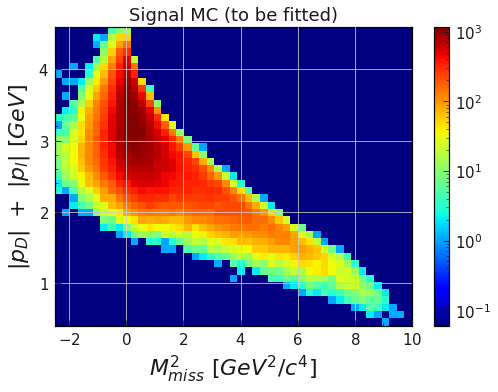

In [169]:
cut='B0_roeMbc_my_mask>4.26'
xedges = np.linspace(-2.5, 10, 48) # -7.5 for weMiss2, -2 for weMiss3, -2.5 for weMiss4
yedges = np.linspace(0.4, 4.6, 42)
variable_x = 'B0_CMS4_weMissM2'
variable_y = 'p_D_l'

(counts, xedges, yedges) = np.histogram2d(df_merged.query(cut)[variable_x], 
                                          df_merged.query(cut)[variable_y],
                                          bins=[xedges, yedges])
counts = counts.T
fig,axs=plt.subplots(ncols=1)
X, Y = np.meshgrid(xedges, yedges)
im=axs.pcolormesh(X, Y, counts, cmap='jet', norm=colors.LogNorm())
axs.set_title('Signal MC (to be fitted)')
axs.set_xlabel('$M_{miss}^2\ [GeV^2/c^4]$')
axs.set_ylabel('$|p_D|\ +\ |p_l|\ [GeV]$')
axs.set_xlim(xedges.min(),xedges.max())
axs.set_ylim(yedges.min(),yedges.max())
#axs.set_aspect('equal')
axs.grid()
fig.colorbar(im)

In [170]:
import ipywidgets as widgets

sliders_norm = {
    f"n{i}" : widgets.FloatSlider(
        1.0,
        min=0.0001,
        max=1.0,
        orientation="vertical",
        continuous_update=False,
        description=f"n{i}",
        layout=widgets.Layout(width='45px')
    )
    for i in range(0, NumOfComp)
}

def plot(**kwargs):
    parameters = model_1.config.suggested_init()
    
    for k in kwargs:
        i = int(k.replace("n", ""))
        parameters[i] = kwargs[k]
        
    fig, axs = plt.subplots(ncols=2,figsize=(14,4))
    X, Y = np.meshgrid(xedges, yedges)
    im0=axs[0].pcolormesh(X, Y,
                          model_1.expected_data(parameters).reshape(counts.shape),
                          cmap='jet', norm=colors.LogNorm())
    im1=axs[1].pcolormesh(X, Y, counts, cmap='jet', norm=colors.LogNorm())

    #axs[0].set_aspect('equal')
    #axs[1].set_aspect('equal')
    axs[0].set_title('template')
    axs[1].set_title('data')
    axs[0].grid()
    axs[1].grid()
    axs[0].set_xlim(xedges.min(),xedges.max())
    axs[0].set_ylim(yedges.min(),yedges.max())
    axs[1].set_xlim(xedges.min(),xedges.max())
    axs[1].set_ylim(yedges.min(),yedges.max())
    fig.colorbar(im0, ax=axs[0])
    fig.colorbar(im1, ax=axs[1])

    print(
        "Negative Log-Likelihood: "
        f"{- model_1.logpdf(parameters, np.concatenate([counts.flat]))[0]:.3f}"
    )
    
interactive_plot = widgets.interactive_output(plot, dict(sliders_norm))
interactive_plot.layout.height = "300px"

def fit(b):
    global parameters, correlations
    parameters, correlations= pyhf.infer.mle.fit(np.concatenate([counts.flat]), model_1, return_uncertainties=True, return_correlations=True)
    sum_event=0
    for k in sliders_norm:
        i = int(k.replace("n", ""))
        sliders_norm[k].value = parameters[i,0]
        template_counts = np.sum(model_1.spec['channels'][0]['samples'][i]['data'])
        component_name = model_1.spec['channels'][0]['samples'][i]['name']
        fitted_counts = round(parameters[i,0] * template_counts)
        fitted_error = round(parameters[i,1] * template_counts)
        print(f'\n{component_name} counts:             {fitted_counts}')
        print(f'{component_name} counts uncertainty: {fitted_error}')
        sum_event+= fitted_counts
        with open(results, 'r+') as f:
            data = yaml.safe_load(f)
            data['signal_e'][component_name]['difference'][chunk]=fitted_counts - len(samples[component_name])
            data['signal_e'][component_name]['errors'][chunk]=fitted_error
            f.seek(0)        # <--- should reset file position to the beginning.
            yaml.dump(data, f, indent=4)
            f.truncate()     # remove remaining part
        
    print(f'\nTotal fitted counts: {sum_event}')
    print(f'Total fitted counts uncertainty: ')
    print(f'Total generated counts: {len(df_merged)}')
    print(f'\nFitting parameters: \n{parameters}')
    print(f'Fitting parameter correlations: \n{correlations}')
#    print(f'uncertainty: {parameters[0][1]}')
    with open(results, 'r+') as f:
        data = yaml.safe_load(f)
        data['signal_e']['sum']['difference'][chunk]=sum_event - len(df_merged)
        f.seek(0)        # <--- should reset file position to the beginning.
        yaml.dump(data, f, indent=4)
        f.truncate()     # remove remaining part
        
button = widgets.Button(description="Fit")
button.on_click(fit)

display(
    button,
    interactive_plot,
    widgets.HBox(
        [widgets.HBox(layout=widgets.Layout(width='45px'))]
        + [sliders_norm[f"n{i}"] for i in range(0, NumOfComp)]
    ),
)

Button(description='Fit', style=ButtonStyle())

Output(layout=Layout(height='300px'))


sig_D_tau_nu counts:             2517
sig_D_tau_nu counts uncertainty: 611

sig_Dst_tau_nu counts:             3137
sig_Dst_tau_nu counts uncertainty: 392

sig_D_l_nu counts:             47117
sig_D_l_nu counts uncertainty: 377

sig_Dst_l_nu counts:             38545
sig_Dst_l_nu counts uncertainty: 457

all_Dstst_tau_nu counts:             0
all_Dstst_tau_nu counts uncertainty: 509

all_Dstst_l_nu counts:             30762
all_Dstst_l_nu counts uncertainty: 470

Total fitted counts: 122078
Total fitted counts uncertainty: 
Total generated counts: 121994

Fitting parameters: 
[[2.88106028e-02 6.98956232e-03]
 [5.73767871e-02 7.17212404e-03]
 [4.43448471e-01 3.54890056e-03]
 [4.77614260e-01 5.66241052e-03]
 [5.40511338e-10 3.34776771e-03]
 [4.42746817e-01 6.76387564e-03]]
Fitting parameter correlations: 
[[ 1.00000000e+00 -8.89925675e-01 -3.89181943e-02  1.44110508e-01
   1.00481232e-04 -6.57075761e-01]
 [-8.89925675e-01  1.00000000e+00  6.65385999e-03 -2.83751309e-02
  -3.87181309e-0

# Plot the fitting results

## Plot fitting difference

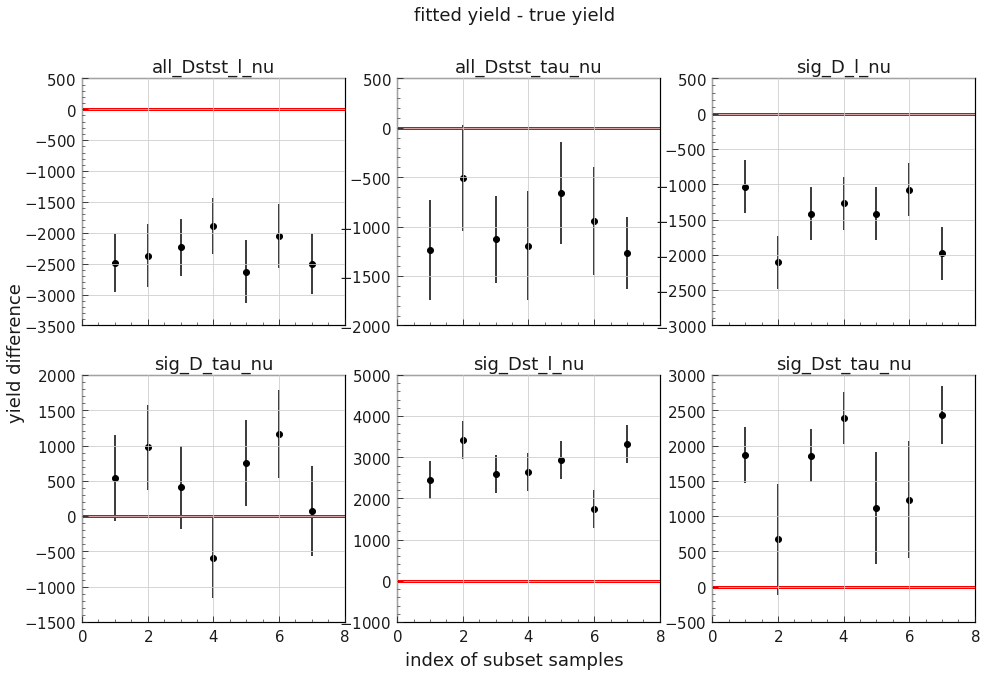

In [171]:
plot_fitting_difference('results_4.yaml')

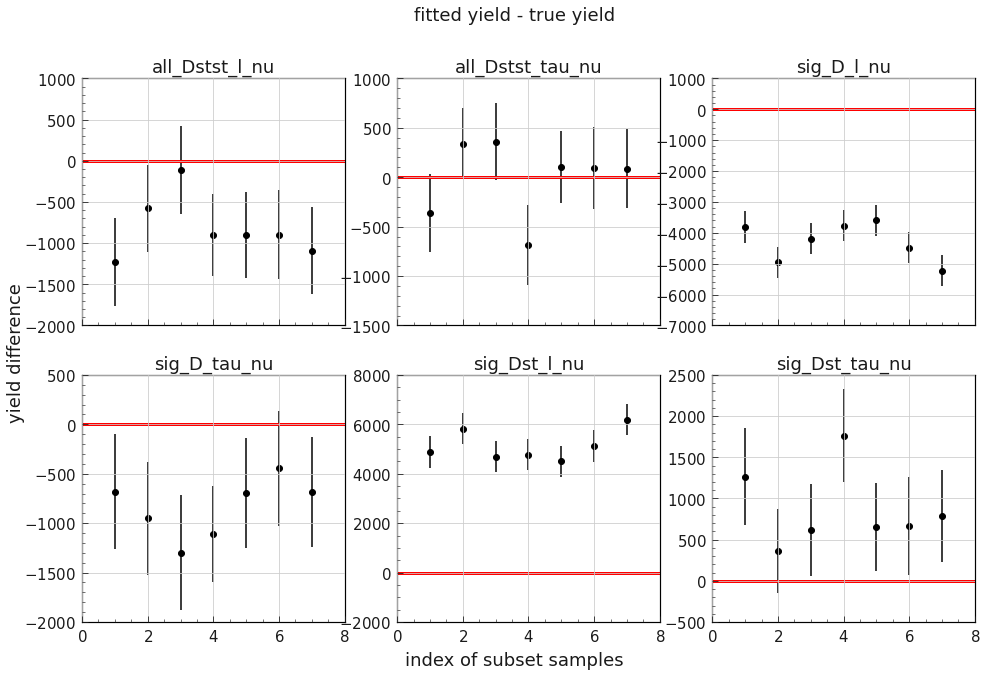

In [172]:
plot_fitting_difference('results_2.yaml')

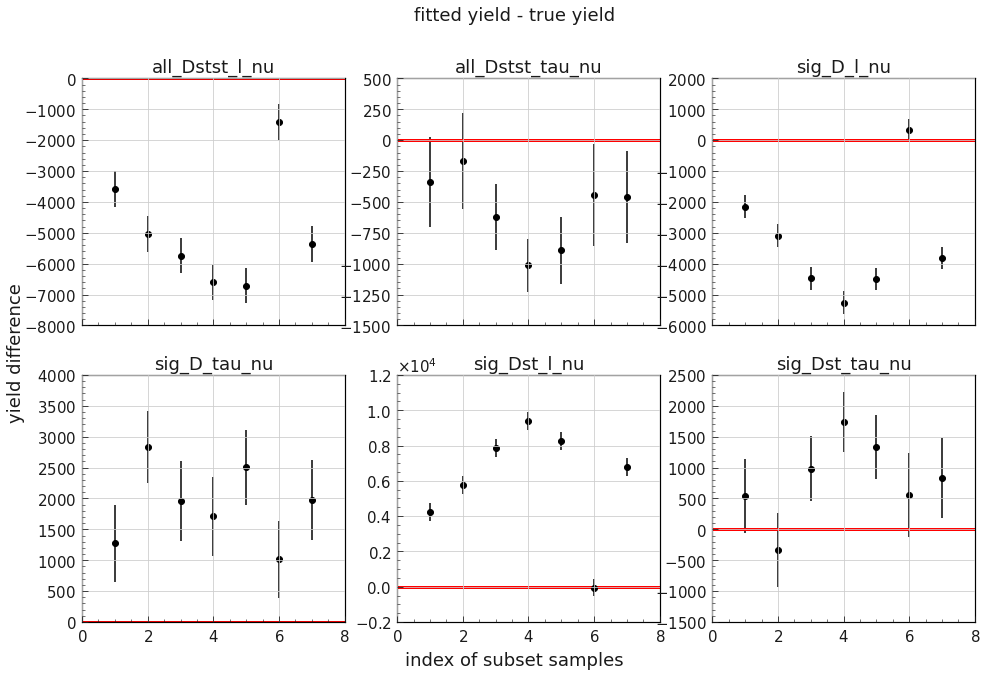

In [6]:
plot_fitting_difference('results_3.yaml')

## Define the slices of projection

In [7]:
from matplotlib import gridspec
import mplhep as hep

print(counts.shape)
p_D_l_slice = 2.5
mm2_slice = 2.4
p_D_l_slice_index, = np.asarray(np.isclose(yedges,p_D_l_slice,atol=0.1)).nonzero()
mm2_slice_index, = np.asarray(np.isclose(xedges,mm2_slice,atol=0.1)).nonzero()
print([mm2_slice_index[0], p_D_l_slice_index[0]])

(41, 47)
[17, 20]


## Plot with mplhep or plt.bar()

In [8]:
# plotting version: residual = data - all_temp
def plot_projection_residual(direction='MM2', slices=False, plot_with='mplhep'):
    fitted_templates = [np.array(model_1.spec['channels'][0]['samples'][i]['data']).reshape(counts.shape) * parameters[i,0] for i in range(NumOfComp)]
    fitted_templates_err = [np.array(model_1.spec['channels'][0]['samples'][i]['data']).reshape(counts.shape) * parameters[i,1] for i in range(NumOfComp)]
    fitted_components_names = [model_1.spec['channels'][0]['samples'][i]['name'] for i in range(NumOfComp)]
    
    def extend(x):
        return np.append(x, x[-1])
    
    def errorband(bins, template_sum, template_err, ax):
        fitted_sum = np.sum(template_sum, axis=0)
        fitted_err = np.sqrt(np.sum(np.array(template_err)**2, axis=0)) # assuming the correlations between each template are 0
        ax.fill_between(bins, extend(fitted_sum - fitted_err), extend(fitted_sum + fitted_err),
        step="post", color="black", alpha=0.3, linewidth=0, zorder=100,)
        
    def plot_with_hep(bins, templates_project, templates_project_err, data, ax1, ax2):
        data_project = data.sum(axis=axis_to_be_summed_over)
        # plot the templates and data
        hep.histplot(templates_project, bin_edges, stack=True, histtype='fill', sort='yield_r', label=fitted_components_names, ax=ax1)
        # errorband(bin_edges, templates_project, templates_project_err, ax1)
        hep.histplot(data_project, bin_edges, histtype='errorbar', color='black', w2=data_project, ax=ax1)
        # plot the residual
        residual = data_project - np.sum(templates_project, axis=0)
        # Error assuming the correlations between data and templates, between each template, are 0
        residual_err = np.sqrt(data_project + np.sum(np.array(templates_project_err)**2, axis=0))
        hep.histplot(residual, bin_edges, histtype='errorbar', color='black', yerr=residual_err, ax=ax2)
        ax2.axhline(y=0, linestyle='-', linewidth=1, color='r')
        
        ax1.grid()
        ax1.set_ylabel('# of counts per bin',fontsize=16)
        ax1.set_xlim(bin_edges.min(), bin_edges.max())
        ax1.set_ylim(0, data_project.max()*1.2)
        ax2.set_ylabel('Residual',fontsize=16)
        ax2.set_xlim(bin_edges.min(), bin_edges.max())
        ax1.legend(bbox_to_anchor=(1,1),ncol=1, fancybox=True, shadow=True,labelspacing=1)
        
    def plot_with_bar(bins, templates_project, templates_project_err, data, ax1, ax2):        
        # calculate the arguments for plotting
        bin_width = bins[1]-bins[0]
        bin_centers = (bins[:-1] + bins[1:]) /2
        data_project = data.sum(axis=axis_to_be_summed_over)
        data_err = np.sqrt(data_project)
        
        # plot the templates
        # sort the components to plot in order of fitted templates_project size
        sorted_indices = sorted(range(NumOfComp), key=lambda i: np.sum(templates_project[i]), reverse = True)
        bottom_hist = np.zeros(data.shape[1-axis_to_be_summed_over])
        for i in sorted_indices:
            binned_counts = templates_project[i]
            ax1.bar(x=bins[:-1], height=binned_counts, bottom=bottom_hist,
                    width=bin_width, align='edge', label=f"{fitted_components_names[i]}")
            bottom_hist = bottom_hist + binned_counts
        # errorband(bin_edges, templates_project, templates_project_err, ax1)
        
        # plot the data
        ax1.errorbar(x=bin_centers, y=data_project, yerr=data_err, fmt='ko')
        # plot the residual
        residual = data_project - np.sum(templates_project, axis=0)
        # Error assuming the correlations between data and templates, between each template, are 0
        residual_err = np.sqrt(data_project + np.sum(np.array(templates_project_err)**2, axis=0))
        ax2.errorbar(x=bin_centers, y=residual, yerr=residual_err, fmt='ko')
        ax2.axhline(y=0, linestyle='-', linewidth=1, color='r')
        
        ax1.grid()
        ax1.set_ylabel('# of counts per bin',fontsize=16)
        ax1.set_xlim(bin_edges.min(), bin_edges.max())
        ax1.set_ylim(0, data_project.max()*1.2)
        ax2.set_ylabel('Residual',fontsize=16)
        ax2.set_xlim(bin_edges.min(), bin_edges.max())
        ax1.legend(bbox_to_anchor=(1,1),ncol=1, fancybox=True, shadow=True,labelspacing=1)        
    
    if direction=='MM2':
        direction_label = '$M_{miss}^2$'
        direction_unit = '$[GeV^2/c^4]$'
        other_direction_label = '$|p_D|\ +\ |p_l|$'
        other_direction_unit = '[GeV]'
        slice_position = p_D_l_slice
        axis_to_be_summed_over = 0
        bin_edges = xedges
        first_slice_index = (p_D_l_slice_index[0]-1)
        second_slice_index = (p_D_l_slice_index[0])
        
        # parameters for slices==True
        fitted_project_slice1 = [temp[:first_slice_index,:].sum(axis=axis_to_be_summed_over) for temp in fitted_templates]
        fitted_project_slice2 = [temp[second_slice_index:,:].sum(axis=axis_to_be_summed_over) for temp in fitted_templates]
        fitted_project_slice1_err = [temp[:first_slice_index,:].sum(axis=axis_to_be_summed_over) for temp in fitted_templates_err]
        fitted_project_slice2_err = [temp[second_slice_index:,:].sum(axis=axis_to_be_summed_over) for temp in fitted_templates_err]
        data_slice1 = counts[:first_slice_index,:]
        data_slice2 = counts[second_slice_index:,:]

        
    elif direction=='p_D_l':
        direction_label = '$|p_D|\ +\ |p_l|$'
        direction_unit = '[GeV]'
        other_direction_label = '$M_{miss}^2$'
        other_direction_unit = '$[GeV^2/c^4]$'
        slice_position = mm2_slice
        axis_to_be_summed_over = 1
        bin_edges = yedges
        first_slice_index = (mm2_slice_index[0]-1)
        second_slice_index = (mm2_slice_index[0])
        
        # parameters for slices==True
        fitted_project_slice1 = [temp[:,:first_slice_index].sum(axis=axis_to_be_summed_over) for temp in fitted_templates]
        fitted_project_slice2 = [temp[:,second_slice_index:].sum(axis=axis_to_be_summed_over) for temp in fitted_templates]
        fitted_project_slice1_err = [temp[:,:first_slice_index].sum(axis=axis_to_be_summed_over) for temp in fitted_templates_err]
        fitted_project_slice2_err = [temp[:,second_slice_index:].sum(axis=axis_to_be_summed_over) for temp in fitted_templates_err]
        data_slice1 = counts[:,:first_slice_index]
        data_slice2 = counts[:,second_slice_index:]
        
        
    else:
        raise ValueError('Current version only supports projection to either MM2 or p_D_l')
    
    if not slices:
        fig = plt.figure(figsize=(6.4,6.4))
        gs = gridspec.GridSpec(2,1, height_ratios=[0.8,0.2])
        ax1 = fig.add_subplot(gs[0])
        ax2 = fig.add_subplot(gs[1])
        #gs.update(hspace=0) 
        fitted_project = [temp.sum(axis=axis_to_be_summed_over) for temp in fitted_templates]
        fitted_project_err = [temp.sum(axis=axis_to_be_summed_over) for temp in fitted_templates_err]
        
        # plot the templates and data and templates_err
        if plot_with=='mplhep':
            plot_with_hep(bin_edges, fitted_project, fitted_project_err, counts, ax1, ax2)
        elif plot_with=='pltbar':
            plot_with_bar(bin_edges, fitted_project, fitted_project_err, counts, ax1, ax2)
        ax1.set_title(f'Fitting projection to {direction_label}')
        ax2.set_xlabel(direction_label)
    
    elif slices:
        fig = plt.figure(figsize=(16,7))
        spec = gridspec.GridSpec(5,2, figure=fig, wspace=1, hspace=0.5)
        ax1 = fig.add_subplot(spec[:-1, 0])
        ax2 = fig.add_subplot(spec[:-1, 1])
        ax3 = fig.add_subplot(spec[-1, 0])
        ax4 = fig.add_subplot(spec[-1, 1])
        #gs.update(hspace=0) 
        
        # plot the templates and data and template_err
        if plot_with=='mplhep':
            plot_with_hep(bin_edges, fitted_project_slice1, fitted_project_slice1_err, data_slice1, ax1, ax3)
            plot_with_hep(bin_edges, fitted_project_slice2, fitted_project_slice2_err, data_slice2, ax2, ax4)
        elif plot_with=='pltbar':
            plot_with_bar(bin_edges, fitted_project_slice1, fitted_project_slice1_err, data_slice1, ax1, ax3)
            plot_with_bar(bin_edges, fitted_project_slice2, fitted_project_slice2_err, data_slice2, ax2, ax4)
            
        ax1.set_title(f'{other_direction_label} < {slice_position}  {other_direction_unit}')
        ax2.set_title(f'{other_direction_label} > {slice_position}  {other_direction_unit}')
        fig.suptitle(f'Fitted projection to {direction_label} in slices of {other_direction_label}')
        fig.supxlabel(direction_label + '  ' + direction_unit)

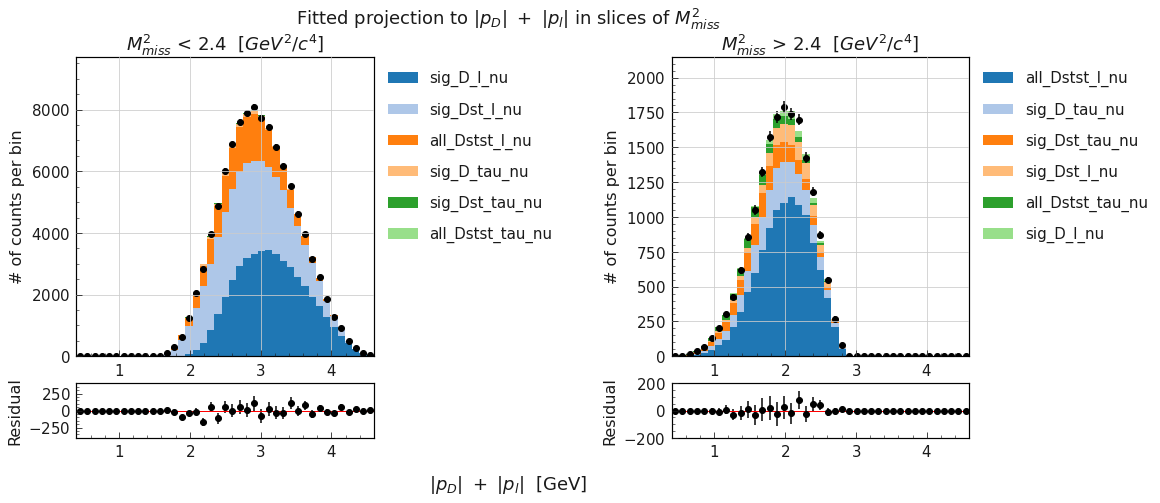

In [9]:
plot_projection_residual(direction='p_D_l',slices=True, plot_with='pltbar')

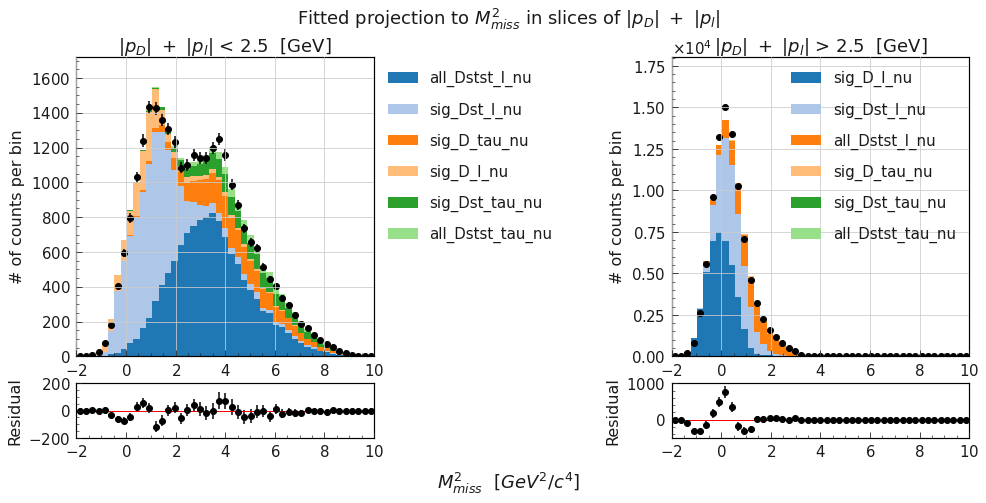

In [10]:
plot_projection_residual(direction='MM2',slices=True, plot_with='pltbar')

In [ ]:
# plotting version: two residual plots, residual_signal = data - all_temp + signal1
def plot_projection_residual(direction='MM2', slices=False, plot_with='mplhep'):
    fitted_templates = [np.array(model_1.spec['channels'][0]['samples'][i]['data']).reshape(counts.shape) * parameters[i,0] for i in range(NumOfComp)]
    fitted_templates_err = [np.array(model_1.spec['channels'][0]['samples'][i]['data']).reshape(counts.shape) * parameters[i,1] for i in range(NumOfComp)]
    fitted_components_names = [model_1.spec['channels'][0]['samples'][i]['name'] for i in range(NumOfComp)]
    
    def extend(x):
        return np.append(x, x[-1])
    
    def errorband(bins, template_sum, template_err, ax):
        fitted_sum = np.sum(template_sum, axis=0)
        fitted_err = np.sqrt(np.sum(np.array(template_err)**2, axis=0)) # assuming the correlations between each template are 0
        ax.fill_between(bins, extend(fitted_sum - fitted_err), extend(fitted_sum + fitted_err),
        step="post", color="black", alpha=0.3, linewidth=0, zorder=100,)
        
    def plot_with_hep(bins, templates_project, templates_project_err, data, signal_name, ax1, ax2, ax3):
        data_project = data.sum(axis=axis_to_be_summed_over)
        # plot the templates and data
        hep.histplot(templates_project, bin_edges, stack=True, histtype='fill', sort='yield_r', label=fitted_components_names, ax=ax1)
        # errorband(bin_edges, templates_project, templates_project_err, ax1)
        hep.histplot(data_project, bin_edges, histtype='errorbar', color='black', w2=data_project, ax=ax1)
        # plot the residual
        signal_index = fitted_components_names.index(signal_name)
        residual = data_project - np.sum(templates_project, axis=0)
        residual_signal = residual + templates_project[signal_index]
        # Error assuming the correlations between data and templates, between each template, are 0
        residual_err = np.sqrt(data_project + np.sum(np.array(templates_project_err)**2, axis=0))
        residual_err_signal = np.sqrt(residual_err**2 - np.array(templates_project_err[signal_index]))
        hep.histplot(residual, bin_edges, histtype='errorbar', color='black', yerr=residual_err, ax=ax2)
        ax2.axhline(y=0, linestyle='-', linewidth=1, color='r')
        hep.histplot(residual_signal, bin_edges, histtype='errorbar', color='black', yerr=residual_err_signal, ax=ax3)
        ax3.axhline(y=0, linestyle='-', linewidth=1, color='r')
        
        ax1.grid()
        ax1.set_ylabel('# of counts per bin',fontsize=16)
        ax1.set_xlim(bin_edges.min(), bin_edges.max())
        ax1.set_ylim(0, data_project.max()*1.2)
        ax2.set_ylabel('Residual',fontsize=16)
        ax2.set_xlim(bin_edges.min(), bin_edges.max())
        ax3.set_ylabel('Data-Bkg',fontsize=16)
        ax3.set_xlim(bin_edges.min(), bin_edges.max())
        ax1.legend(bbox_to_anchor=(1,1),ncol=1, fancybox=True, shadow=True,labelspacing=1)
        
    def plot_with_bar(bins, templates_project, templates_project_err, data, signal_name, ax1, ax2, ax3):        
        # calculate the arguments for plotting
        bin_width = bins[1]-bins[0]
        bin_centers = (bins[:-1] + bins[1:]) /2
        data_project = data.sum(axis=axis_to_be_summed_over)
        data_err = np.sqrt(data_project)
        
        # plot the templates
        # sort the components to plot in order of fitted templates_project size
        sorted_indices = sorted(range(NumOfComp), key=lambda i: np.sum(templates_project[i]), reverse = True)
        bottom_hist = np.zeros(data.shape[1-axis_to_be_summed_over])
        for i in sorted_indices:
            binned_counts = templates_project[i]
            ax1.bar(x=bins[:-1], height=binned_counts, bottom=bottom_hist,
                    width=bin_width, align='edge', label=f"{fitted_components_names[i]}")
            bottom_hist = bottom_hist + binned_counts
        # errorband(bin_edges, templates_project, templates_project_err, ax1)
        
        # plot the data
        ax1.errorbar(x=bin_centers, y=data_project, yerr=data_err, fmt='ko')
        # plot the residual
        signal_index = fitted_components_names.index(signal_name)
        residual = data_project - np.sum(templates_project, axis=0)
        residual_signal = residual + templates_project[signal_index]
        # Error assuming the correlations between data and templates, between each template, are 0
        residual_err = np.sqrt(data_project + np.sum(np.array(templates_project_err)**2, axis=0))
        residual_err_signal = np.sqrt(residual_err**2 - np.array(templates_project_err[signal_index]))
        ax2.errorbar(x=bin_centers, y=residual, yerr=residual_err, fmt='ko')
        ax2.axhline(y=0, linestyle='-', linewidth=1, color='r')
        ax3.errorbar(x=bin_centers, y=residual_signal, yerr=residual_err_signal, fmt='ko')
        ax3.axhline(y=0, linestyle='-', linewidth=1, color='r')
                
        ax1.grid()
        ax1.set_ylabel('# of counts per bin',fontsize=16)
        ax1.set_xlim(bin_edges.min(), bin_edges.max())
        ax1.set_ylim(0, data_project.max()*1.2)
        ax2.set_ylabel('Residual',fontsize=16)
        ax2.set_xlim(bin_edges.min(), bin_edges.max())
        ax3.set_ylabel('Data-Bkg',fontsize=16)
        ax3.set_xlim(bin_edges.min(), bin_edges.max())
        ax1.legend(bbox_to_anchor=(1,1),ncol=1, fancybox=True, shadow=True,labelspacing=1)       
    
    if direction=='MM2':
        direction_label = '$M_{miss}^2$'
        direction_unit = '$[GeV^2/c^4]$'
        other_direction_label = '$|p_D|\ +\ |p_l|$'
        other_direction_unit = '[GeV]'
        slice1_signal = 'D_tau_nu'
        slice2_signal = 'D_l_nu'
        slice_position = p_D_l_slice
        axis_to_be_summed_over = 0
        bin_edges = xedges
        first_slice_index = (p_D_l_slice_index[0]-1)
        second_slice_index = (p_D_l_slice_index[0])
        
        # parameters for slices==True
        fitted_project_slice1 = [temp[:first_slice_index,:].sum(axis=axis_to_be_summed_over) for temp in fitted_templates]
        fitted_project_slice2 = [temp[second_slice_index:,:].sum(axis=axis_to_be_summed_over) for temp in fitted_templates]
        fitted_project_slice1_err = [temp[:first_slice_index,:].sum(axis=axis_to_be_summed_over) for temp in fitted_templates_err]
        fitted_project_slice2_err = [temp[second_slice_index:,:].sum(axis=axis_to_be_summed_over) for temp in fitted_templates_err]
        data_slice1 = counts[:first_slice_index,:]
        data_slice2 = counts[second_slice_index:,:]
        
    elif direction=='p_D_l':
        direction_label = '$|p_D|\ +\ |p_l|$'
        direction_unit = '[GeV]'
        other_direction_label = '$M_{miss}^2$'
        other_direction_unit = '$[GeV^2/c^4]$'
        slice1_signal = 'D_l_nu'
        slice2_signal = 'D_tau_nu'
        slice_position = mm2_slice
        axis_to_be_summed_over = 1
        bin_edges = yedges
        first_slice_index = (mm2_slice_index[0]-1)
        second_slice_index = (mm2_slice_index[0])
        
        # parameters for slices==True
        fitted_project_slice1 = [temp[:,:first_slice_index].sum(axis=axis_to_be_summed_over) for temp in fitted_templates]
        fitted_project_slice2 = [temp[:,second_slice_index:].sum(axis=axis_to_be_summed_over) for temp in fitted_templates]
        fitted_project_slice1_err = [temp[:,:first_slice_index].sum(axis=axis_to_be_summed_over) for temp in fitted_templates_err]
        fitted_project_slice2_err = [temp[:,second_slice_index:].sum(axis=axis_to_be_summed_over) for temp in fitted_templates_err]
        data_slice1 = counts[:,:first_slice_index]
        data_slice2 = counts[:,second_slice_index:]

        
    else:
        raise ValueError('Current version only supports projection to either MM2 or p_D_l')
    
    if not slices:
        fig = plt.figure(figsize=(6.4,6.4))
        gs = gridspec.GridSpec(3,1, height_ratios=[0.7,0.15,0.15])
        ax1 = fig.add_subplot(gs[0])
        ax2 = fig.add_subplot(gs[1])
        ax3 = fig.add_subplot(gs[2])
        gs.update(hspace=0.3) 
        fitted_project = [temp.sum(axis=axis_to_be_summed_over) for temp in fitted_templates]
        fitted_project_err = [temp.sum(axis=axis_to_be_summed_over) for temp in fitted_templates_err]
        
        # plot the templates and data and templates_err
        if plot_with=='mplhep':
            plot_with_hep(bin_edges, fitted_project, fitted_project_err, counts, 'D_tau_nu', ax1, ax2,ax3)
        elif plot_with=='pltbar':
            plot_with_bar(bin_edges, fitted_project, fitted_project_err, counts, 'D_tau_nu', ax1, ax2,ax3)
        ax1.set_title(f'Fitting projection to {direction_label}')
        ax3.set_xlabel(direction_label)
    
    elif slices:
        fig = plt.figure(figsize=(16,7))
        spec = gridspec.GridSpec(6,2, figure=fig, wspace=1, hspace=0.5)
        ax1 = fig.add_subplot(spec[:-2, 0])
        ax2 = fig.add_subplot(spec[:-2, 1])
        ax3 = fig.add_subplot(spec[-2, 0])
        ax4 = fig.add_subplot(spec[-2, 1])
        ax5 = fig.add_subplot(spec[-1, 0])
        ax6 = fig.add_subplot(spec[-1, 1])
        #gs.update(hspace=0) 
        
        # plot the templates and data and template_err
        if plot_with=='mplhep':
            plot_with_hep(bin_edges, fitted_project_slice1, fitted_project_slice1_err, data_slice1, slice1_signal, ax1, ax3, ax5)
            plot_with_hep(bin_edges, fitted_project_slice2, fitted_project_slice2_err, data_slice2, slice2_signal, ax2, ax4, ax6)
        elif plot_with=='pltbar':
            plot_with_bar(bin_edges, fitted_project_slice1, fitted_project_slice1_err, data_slice1, slice1_signal, ax1, ax3, ax5)
            plot_with_bar(bin_edges, fitted_project_slice2, fitted_project_slice2_err, data_slice2, slice2_signal, ax2, ax4, ax6)
            
        ax1.set_title(f'{other_direction_label} < {slice_position}  {other_direction_unit}')
        ax2.set_title(f'{other_direction_label} > {slice_position}  {other_direction_unit}')
        fig.suptitle(f'Fitted projection to {direction_label} in slices of {other_direction_label}')
        fig.supxlabel(direction_label + '  ' + direction_unit)

In [ ]:
# plotting version: residual_signals = data - all_temp + signal1 + signal2
def plot_projection_residual(direction='MM2', slices=False, plot_with='mplhep'):
    fitted_templates = [np.array(model_1.spec['channels'][0]['samples'][i]['data']).reshape(counts.shape) * parameters[i,0] for i in range(NumOfComp)]
    fitted_templates_err = [np.array(model_1.spec['channels'][0]['samples'][i]['data']).reshape(counts.shape) * parameters[i,1] for i in range(NumOfComp)]
    fitted_components_names = [model_1.spec['channels'][0]['samples'][i]['name'] for i in range(NumOfComp)]
    
    def extend(x):
        return np.append(x, x[-1])
    
    def errorband(bins, template_sum, template_err, ax):
        fitted_sum = np.sum(template_sum, axis=0)
        fitted_err = np.sqrt(np.sum(np.array(template_err)**2, axis=0)) # assuming the correlations between each template are 0
        ax.fill_between(bins, extend(fitted_sum - fitted_err), extend(fitted_sum + fitted_err),
        step="post", color="black", alpha=0.3, linewidth=0, zorder=100,)
        
    def plot_with_hep(bins, templates_project, templates_project_err, data, signal_names, ax1, ax2):
        data_project = data.sum(axis=axis_to_be_summed_over)
        # plot the templates and data
        hep.histplot(templates_project, bin_edges, stack=True, histtype='fill', sort='yield_r', label=fitted_components_names, ax=ax1)
        # errorband(bin_edges, templates_project, templates_project_err, ax1)
        hep.histplot(data_project, bin_edges, histtype='errorbar', color='black', w2=data_project, ax=ax1)
        # plot the residual
        signal_index1 = fitted_components_names.index(signal_names[0])
        signal_index2 = fitted_components_names.index(signal_names[1])
        residual = data_project - np.sum(templates_project, axis=0)
        residual_signals = residual + templates_project[signal_index1] + templates_project[signal_index2]
        # Error assuming the correlations between data and templates, between each template, are 0
        residual_err = np.sqrt(data_project + np.sum(np.array(templates_project_err)**2, axis=0))
        residual_err_signals = np.sqrt(residual_err**2 - np.array(templates_project_err[signal_index1]) - np.array(templates_project_err[signal_index2]))
        hep.histplot(residual_signals, bin_edges, histtype='errorbar', color='black', yerr=residual_err_signals, ax=ax2)
        ax2.axhline(y=0, linestyle='-', linewidth=1, color='r')
        
        ax1.grid()
        ax1.set_ylabel('# of counts per bin',fontsize=16)
        ax1.set_xlim(bin_edges.min(), bin_edges.max())
        ax1.set_ylim(0, data_project.max()*1.2)
        ax2.set_ylabel('Data-Bkg',fontsize=16)
        ax2.set_xlim(bin_edges.min(), bin_edges.max())
        ax1.legend(bbox_to_anchor=(1,1),ncol=1, fancybox=True, shadow=True,labelspacing=1)
        
    def plot_with_bar(bins, templates_project, templates_project_err, data, signal_names, ax1, ax2):        
        # calculate the arguments for plotting
        bin_width = bins[1]-bins[0]
        bin_centers = (bins[:-1] + bins[1:]) /2
        data_project = data.sum(axis=axis_to_be_summed_over)
        data_err = np.sqrt(data_project)
        
        # plot the templates
        # sort the components to plot in order of fitted templates_project size
        sorted_indices = sorted(range(NumOfComp), key=lambda i: np.sum(templates_project[i]), reverse = True)
        bottom_hist = np.zeros(data.shape[1-axis_to_be_summed_over])
        for i in sorted_indices:
            binned_counts = templates_project[i]
            ax1.bar(x=bins[:-1], height=binned_counts, bottom=bottom_hist,
                    width=bin_width, align='edge', label=f"{fitted_components_names[i]}")
            bottom_hist = bottom_hist + binned_counts
        # errorband(bin_edges, templates_project, templates_project_err, ax1)
        
        # plot the data
        ax1.errorbar(x=bin_centers, y=data_project, yerr=data_err, fmt='ko')
        # plot the residual
        signal_index1 = fitted_components_names.index(signal_names[0])
        signal_index2 = fitted_components_names.index(signal_names[1])
        residual = data_project - np.sum(templates_project, axis=0)
        residual_signals = residual + templates_project[signal_index1] + templates_project[signal_index2]
        # Error assuming the correlations between data and templates, between each template, are 0
        residual_err = np.sqrt(data_project + np.sum(np.array(templates_project_err)**2, axis=0))
        residual_err_signals = np.sqrt(residual_err**2 - np.array(templates_project_err[signal_index1]) - np.array(templates_project_err[signal_index2]))
        ax2.errorbar(x=bin_centers, y=residual_signals, yerr=residual_err_signals, fmt='ko')
        ax2.axhline(y=0, linestyle='-', linewidth=1, color='r')
        
        ax1.grid()
        ax1.set_ylabel('# of counts per bin',fontsize=16)
        ax1.set_xlim(bin_edges.min(), bin_edges.max())
        ax1.set_ylim(0, data_project.max()*1.2)
        ax2.set_ylabel('Data-Bkg',fontsize=16)
        ax2.set_xlim(bin_edges.min(), bin_edges.max())
        ax1.legend(bbox_to_anchor=(1,1),ncol=1, fancybox=True, shadow=True,labelspacing=1)
    
    if direction=='MM2':
        direction_label = '$M_{miss}^2$'
        direction_unit = '$[GeV^2/c^4]$'
        other_direction_label = '$|p_D|\ +\ |p_l|$'
        other_direction_unit = '[GeV]'
        slice1_signals = ['D_tau_nu', 'Dst_tau_nu']
        slice2_signals = ['D_l_nu', 'Dst_l_nu']
        slice_position = p_D_l_slice
        axis_to_be_summed_over = 0
        bin_edges = xedges
        first_slice_index = (p_D_l_slice_index[0]-1)
        second_slice_index = (p_D_l_slice_index[0])
        
        # parameters for slices==True
        fitted_project_slice1 = [temp[:first_slice_index,:].sum(axis=axis_to_be_summed_over) for temp in fitted_templates]
        fitted_project_slice2 = [temp[second_slice_index:,:].sum(axis=axis_to_be_summed_over) for temp in fitted_templates]
        fitted_project_slice1_err = [temp[:first_slice_index,:].sum(axis=axis_to_be_summed_over) for temp in fitted_templates_err]
        fitted_project_slice2_err = [temp[second_slice_index:,:].sum(axis=axis_to_be_summed_over) for temp in fitted_templates_err]
        data_slice1 = counts[:first_slice_index,:]
        data_slice2 = counts[second_slice_index:,:]
        
    elif direction=='p_D_l':
        direction_label = '$|p_D|\ +\ |p_l|$'
        direction_unit = '[GeV]'
        other_direction_label = '$M_{miss}^2$'
        other_direction_unit = '$[GeV^2/c^4]$'
        slice1_signals = ['D_l_nu', 'Dst_l_nu']
        slice2_signals = ['D_tau_nu', 'Dst_tau_nu']
        slice_position = mm2_slice
        axis_to_be_summed_over = 1
        bin_edges = yedges
        first_slice_index = (mm2_slice_index[0]-1)
        second_slice_index = (mm2_slice_index[0])
        
        # parameters for slices==True
        fitted_project_slice1 = [temp[:,:first_slice_index].sum(axis=axis_to_be_summed_over) for temp in fitted_templates]
        fitted_project_slice2 = [temp[:,second_slice_index:].sum(axis=axis_to_be_summed_over) for temp in fitted_templates]
        fitted_project_slice1_err = [temp[:,:first_slice_index].sum(axis=axis_to_be_summed_over) for temp in fitted_templates_err]
        fitted_project_slice2_err = [temp[:,second_slice_index:].sum(axis=axis_to_be_summed_over) for temp in fitted_templates_err]
        data_slice1 = counts[:,:first_slice_index]
        data_slice2 = counts[:,second_slice_index:]
        
        
    else:
        raise ValueError('Current version only supports projection to either MM2 or p_D_l')
    
    if not slices:
        fig = plt.figure(figsize=(6.4,6.4))
        gs = gridspec.GridSpec(3,1, height_ratios=[0.8,0.2])
        ax1 = fig.add_subplot(gs[0])
        ax2 = fig.add_subplot(gs[1])
        #gs.update(hspace=0.3) 
        fitted_project = [temp.sum(axis=axis_to_be_summed_over) for temp in fitted_templates]
        fitted_project_err = [temp.sum(axis=axis_to_be_summed_over) for temp in fitted_templates_err]
        
        # plot the templates and data and templates_err
        if plot_with=='mplhep':
            plot_with_hep(bin_edges, fitted_project, fitted_project_err, counts, 'D_tau_nu', ax1, ax2)
        elif plot_with=='pltbar':
            plot_with_bar(bin_edges, fitted_project, fitted_project_err, counts, 'D_tau_nu', ax1, ax2)
        ax1.set_title(f'Fitting projection to {direction_label}')
        ax2.set_xlabel(direction_label)
    
    elif slices:
        fig = plt.figure(figsize=(16,7))
        spec = gridspec.GridSpec(5,2, figure=fig, wspace=1, hspace=0.5)
        ax1 = fig.add_subplot(spec[:-1, 0])
        ax2 = fig.add_subplot(spec[:-1, 1])
        ax3 = fig.add_subplot(spec[-1, 0])
        ax4 = fig.add_subplot(spec[-1, 1])
        #gs.update(hspace=0) 
        
        # plot the templates and data and template_err
        if plot_with=='mplhep':
            plot_with_hep(bin_edges, fitted_project_slice1, fitted_project_slice1_err, data_slice1, slice1_signals, ax1, ax3)
            plot_with_hep(bin_edges, fitted_project_slice2, fitted_project_slice2_err, data_slice2, slice2_signals, ax2, ax4)
        elif plot_with=='pltbar':
            plot_with_bar(bin_edges, fitted_project_slice1, fitted_project_slice1_err, data_slice1, slice1_signals, ax1, ax3)
            plot_with_bar(bin_edges, fitted_project_slice2, fitted_project_slice2_err, data_slice2, slice2_signals, ax2, ax4)
            
        ax1.set_title(f'{other_direction_label} < {slice_position}  {other_direction_unit}')
        ax2.set_title(f'{other_direction_label} > {slice_position}  {other_direction_unit}')
        fig.suptitle(f'Fitted projection to {direction_label} in slices of {other_direction_label}')
        fig.supxlabel(direction_label + '  ' + direction_unit)

## Correlations

<ipython-input-19-58cfba154b31>:4: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  im0=axs.pcolormesh(X, Y,correlations.T)


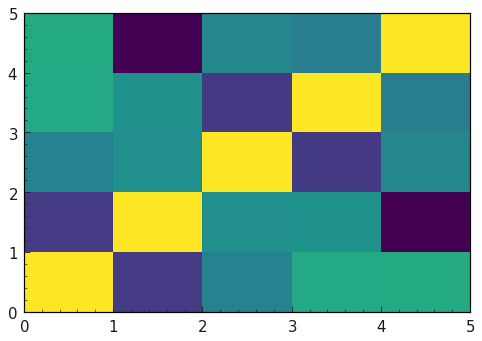

In [19]:
fig, axs = plt.subplots()
a1=np.linspace(0, NumOfComp - 1, NumOfComp)
X, Y = np.meshgrid(a1, a1)
im0=axs.pcolormesh(X, Y,correlations.T)

# 4. Get fitting templates

In [ ]:
# apply BDTs
# plot mm2, mm2 vs p_D_l
# save the templates

In [8]:
import basf2_mva
import pandas

identifier_1 = '/home/belle/zhangboy/R_D/Generic_MC14rd/Continuum_Suppression/MVA1_FastBDT.xml'
test_1 = '../Ntuples/MC_eidglobal_10k_cut.root'
output_file_1 = '../Ntuples/MC_eidglobal_10k_MVA1.root'

identifier_1_5 = '/home/belle/zhangboy/R_D/Generic_MC14rd/B_bkg_Suppression/MVA1_5/MVA1_5_FastBDT.xml'
test_1_5 = '../Ntuples/MC_eidglobal_10k_cut.root'
output_file_1_5 = '../Ntuples/MC_eidglobal_10k_MVA1_5.root'

output_file_1_5_applied = '../Ntuples/MC_eidglobal_10k_MVA1_5_applied.root'

identifier_2_1 = '/home/belle/zhangboy/R_D/Generic_MC14rd/B_bkg_Suppression/MVA2/MVA2_1_FastBDT.xml'
test_2_1 = output_file_1_5_applied
output_file_2_1 = '../Ntuples/MC_eidglobal_10k_MVA2_1.root'
output_file_2_1_applied = '../Ntuples/MC_eidglobal_10k_MVA2_1_applied.root'

In [9]:
# apply CS BDT identifier_1, merge data file and mva output, rename the column
basf2_mva.expert(basf2_mva.vector(identifier_1),  # weightfile
                 basf2_mva.vector(test_1),
                 'B0', output_file_1)

df1 = df_cut.drop_duplicates(subset=['__experiment__','__run__','__event__','__production__','__candidate__']).reset_index(drop=True)
df2 = root_pandas.read_root(output_file_1)
print(len(df1)==len(df2))
df_1 = pandas.concat([df1,df2],axis=1)

df_1=df_1.rename(columns={"__slhome__slbelle__slzhangboy__slR_D__slGeneric_MC14rd__slContinuum_Suppression__slMVA1_FastBDT__ptxml": "MVA1_output"})
df_1=df_1.drop(columns=['__slhome__slbelle__slzhangboy__slR_D__slGeneric_MC14rd__slContinuum_Suppression__slMVA1_FastBDT__ptxml_isSignal'])

# apply BDT 1_5 identifier_1_5, merge, rename, change the output type, save
basf2_mva.expert(basf2_mva.vector(identifier_1_5),  # weightfile
                 basf2_mva.vector(test_1_5),
                 'B0', output_file_1_5)

df3 = root_pandas.read_root(output_file_1_5)
print(len(df_1)==len(df3))
df_1_5 = pandas.concat([df_1,df3],axis=1)

df_1_5=df_1_5.rename(columns={"__slhome__slbelle__slzhangboy__slR_D__slGeneric_MC14rd__slB_bkg_Suppression__slMVA1_5__slMVA1_5_FastBDT__ptxml": "MVA1_5_output"})
df_1_5=df_1_5.drop(columns=['__slhome__slbelle__slzhangboy__slR_D__slGeneric_MC14rd__slB_bkg_Suppression__slMVA1_5__slMVA1_5_FastBDT__ptxml_isSignal'])

df_1_5.MVA1_5_output=np.float64(df_1_5.MVA1_5_output)
print(type(df_1_5.MVA1_5_output[0]))
print(type(df_1_5.isSignal[0]))

df_1_5.to_root(output_file_1_5_applied, key='B0')

# apply BDT 2_1 identifier_2_1, merge, rename, save
basf2_mva.expert(basf2_mva.vector(identifier_2_1),  # weightfile
                 basf2_mva.vector(test_2_1),
                 'B0', output_file_2_1)

df4 = root_pandas.read_root(output_file_2_1)
print(len(df_1_5)==len(df4))
df_2_1 = pandas.concat([df_1_5, df4],axis=1)
print(len(df_1_5)==len(df_2_1))

df_2_1=df_2_1.rename(columns={"__slhome__slbelle__slzhangboy__slR_D__slGeneric_MC14rd__slB_bkg_Suppression__slMVA2__slMVA2_1_FastBDT__ptxml": "MVA2_1_output"})
df_2_1=df_2_1.drop(columns=['__slhome__slbelle__slzhangboy__slR_D__slGeneric_MC14rd__slB_bkg_Suppression__slMVA2__slMVA2_1_FastBDT__ptxml_isSignal'])

df_2_1.to_root(output_file_2_1_applied, key='B0')

[INFO] Elapsed application time in ms 19.8755 for MVA1_FastBDT.xml
[WARNING] String passed to makeROOTCompatible contains double-underscore __, which is used internally for escaping special characters. It is recommended to avoid this. However escaping a string twice with makeROOTCompatible is safe, but will print this warning. Passed string: __slhome__slbelle__slzhangboy__slR_D__slGeneric_MC14rd__slContinuum_Suppression__slMVA1_FastBDT__ptxml_isSignal
False
[INFO] Elapsed application time in ms 17.8737 for MVA1_5_FastBDT.xml
[WARNING] String passed to makeROOTCompatible contains double-underscore __, which is used internally for escaping special characters. It is recommended to avoid this. However escaping a string twice with makeROOTCompatible is safe, but will print this warning. Passed string: __slhome__slbelle__slzhangboy__slR_D__slGeneric_MC14rd__slB_bkg_Suppression__slMVA1_5__slMVA1_5_FastBDT__ptxml_isSignal
True
<class 'numpy.float64'>
<class 'numpy.float64'>


/cvmfs/belle.cern.ch/el7/externals/v01-10-02/Linux_x86_64/common/lib/python3.8/site-packages/root_numpy/_tree.py:575: UserWarning: converter for dtype('O') is not implemented (skipping)
  cobj = _librootnumpy.array2tree_toCObj(arr, name=name, tree=incobj)


[INFO] Elapsed application time in ms 16.9586 for MVA2_1_FastBDT.xml
[WARNING] String passed to makeROOTCompatible contains double-underscore __, which is used internally for escaping special characters. It is recommended to avoid this. However escaping a string twice with makeROOTCompatible is safe, but will print this warning. Passed string: __slhome__slbelle__slzhangboy__slR_D__slGeneric_MC14rd__slB_bkg_Suppression__slMVA2__slMVA2_1_FastBDT__ptxml_isSignal
True
True


In [10]:
df_2_1.columns
len(df_2_1)

1589